# User Behavior Classification


## Objectif

- Exploration descriptive et visualisations clés
- Préparation/encodage des variables et normalisation
- Tuning de plusieurs modèles supervisés (LogReg, SVM, RandomForest, XGBoost)
- Comparaison de performances, interprétation et sauvegarde du meilleur pipeline


### 1️⃣ Import des librairies


In [1]:
import math
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

RANDOM_STATE = 42


### 2️⃣ Chargement et aperçu des données


In [2]:
from feature_builder import build_feature_dataframe

df_features = build_feature_dataframe()
print(f"Shape: {df_features.shape}")
display(df_features.head())


Shape: (3279, 90)


,user,browser,browser_code,total_tokens,nb_actions,nb_time_marks,nb_unique_actions,ratio_unique_actions,nb_screens,nb_unique_screens,nb_confs,nb_unique_confs,nb_chaines,nb_unique_chaines,vitesse_moyenne,count_dialogue_actions,count_bouton_actions,count_saisie_actions,count_toast_actions,count_filtrage_actions,count_double_clic_actions,main_action,main_action_share,main_screen,main_conf,main_chaine,actions_per_time_span,time_total,time_mean,time_std,time_min,time_max,time_span,time_count,avg_time_gap,action_count__execution_d_un_bouton,action_count__saisie_dans_un_champ,action_count__selection_d_un_ecran,action_count__fermeture_d_une_dialogue,action_count__affichage_d_une_dialogue,action_count__lancement_d_une_action_generique,action_count__selection_dun_onglet,action_count__raccourci,action_count__creation_d_un_ecran,action_count__chainage,action_count__double_clic,action_count__retour_sur_un_ecran,action_count__affichage_d_un_toast,action_count__clic_sur_une_grille_d_historique_de_recherche,action_count__entree_en_saisie_dans_un_formulaire,action_count__filtrage_tri,action_count__selection_d_un_flag,action_count__lancement_d_une_stat,action_count__lancement_d_un_tableau_de_bord,action_count__action_de_table,screen_count__maint,screen_count__infologic_core_gui_controllers_blankcontroller,screen_count__infologic_core_fichierscontroller,screen_count__infologic_crm_modules_crm_planning_planning_planningcontroller,screen_count__dev,screen_count__infologic_infoc_statmodif_fichierbase_statfbcontroller,screen_count__infologic_core_gui_controllers_nested_inputformnestedwindow,screen_count__infologic_orga_modules_or_fichiertravail_instanceform,screen_count__infologic_core_accueil_accueilcontroller,screen_count__infologic_core_gui_controllers_nested_homeview_inputformhomeview,screen_count__param,screen_count__infologic_crm_modules_crm_compte_compteform,screen_count__infologic_acti_modules_at_activites_ficheactivite_actificheactivitecontroller,screen_count__bug,screen_count__testobs,conf_count__def_03_24,conf_count__def_07_23,conf_count__std,conf_count__installateur,conf_count__telem_minimal,conf_count__001,conf_count__mt_appeln1,conf_count__accueil_inst,conf_count__005,conf_count__dispatch,chaine_count__vt,chaine_count__gp,chaine_count__edi,chaine_count__tec,chaine_count__ot,chaine_count__sv,chaine_count__gesco,chaine_count__jcp,chaine_count__st,chaine_count__web
0,nuh,Firefox,3,3128,2514,614,19,0.008,191,7,7,3,899,2,0.852,719,698,198,311,161,87,Exécution d'un bouton,0.278,MAINT,DEF_03/24,JCP,0.867,895130.0,1457.866,839.342,5.0,2905.0,2900.0,614,4.731,698,198,23,369,350,124,6,0,72,8,87,2,311,1,0,161,0,85,0,11,89,4,0,0,0,0,1,0,5,85,0,0,4,0,0,3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,822,0,0
1,muz,Google Chrome,0,136,90,46,11,0.122,8,5,4,2,43,2,0.365,4,33,34,1,0,0,Saisie dans un champ,0.378,infologic.orga.modules.OR_FICHIERTRAVAIL.Insta...,TELEM_MINIMAL,DB,0.400,5405.0,117.500,66.380,5.0,230.0,225.0,46,5.000,33,34,3,2,2,5,3,1,3,3,0,0,1,0,0,0,0,0,0,0,2,1,0,0,0,0,1,3,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0
2,zrx,Microsoft Edge,1,766,608,158,21,0.035,94,17,35,7,52,2,0.796,73,122,46,7,1,22,Exécution d'un bouton,0.201,DEMTEST,DEF_07/23,MES,0.816,59285.0,375.222,213.150,5.0,750.0,745.0,158,4.745,122,46,68,38,35,35,21,39,36,32,22,4,7,72,0,1,0,0,0,6,0,5,1,9,10,0,5,6,0,0,5,0,2,0,15,0,13,2,8,4,3,0,4,0,0,0,13,0,0,0,0,0,0,0,0
3,pou,Firefox,3,1199,886,313,19,0.021,249,10,9,4,203,1,0.596,84,279,84,2,5,2,Exécution d'un bouton,0.315,MAINT,DEF_03/24,JCP,0.615,229405.0,732.923,415.740,5.0,1445.0,1440.0,313,4.615,279,84,50,42,42,26,0,0,22,23,2,17,2,121,0,5,60,101,0,7,117,4,29,1,0,2,2,1,2,89,0,0,2,0,0,4,0,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,203,0,0
4,ald,Google Chrome,0,233,173,60,14,0.081,21,8,7,4,11,2,0.607,20,60,36,1,0,2,Exécution d'un bouton,0.347,MAINT,INSTALLATEUR,GP,0.641,8185.0,136.417,79.210,5.0,275.0,270.0,60,4.576,60,14,19,10,10,7,0,0,10,4,2,0,1,10,22,0,0,0,0,3,6,0,3,3,0,0,1,2,0,0,0,0,0,0,1,2,1,0,2,2,0,0,0,0,0,0,8,0,0,0,0,0,0,3,0


In [3]:
print("Informations générales :")
df_features.info()

missing_values = (
    df_features.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="missing_values")
)
display(missing_values.head(20))


Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3279 entries, 0 to 3278
Data columns (total 90 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   user                                                                                         3279 non-null   object 
 1   browser                                                                                      3279 non-null   object 
 2   browser_code                                                                                 3279 non-null   int64  
 3   total_tokens                                                                                 3279 non-null   int64  
 4   nb_actions                                                                                   3279 non-null   int64  
 5   nb_time_m

,missing_values
main_chaine,1051
main_conf,153
main_action,1
main_screen,1
nb_actions,0
nb_time_marks,0
browser_code,0
total_tokens,0
user,0
browser,0


### 3️⃣ Exploration (EDA)


In [ ]:
print("Statistiques descriptives (variables numériques) :")
display(df_features.describe().T)


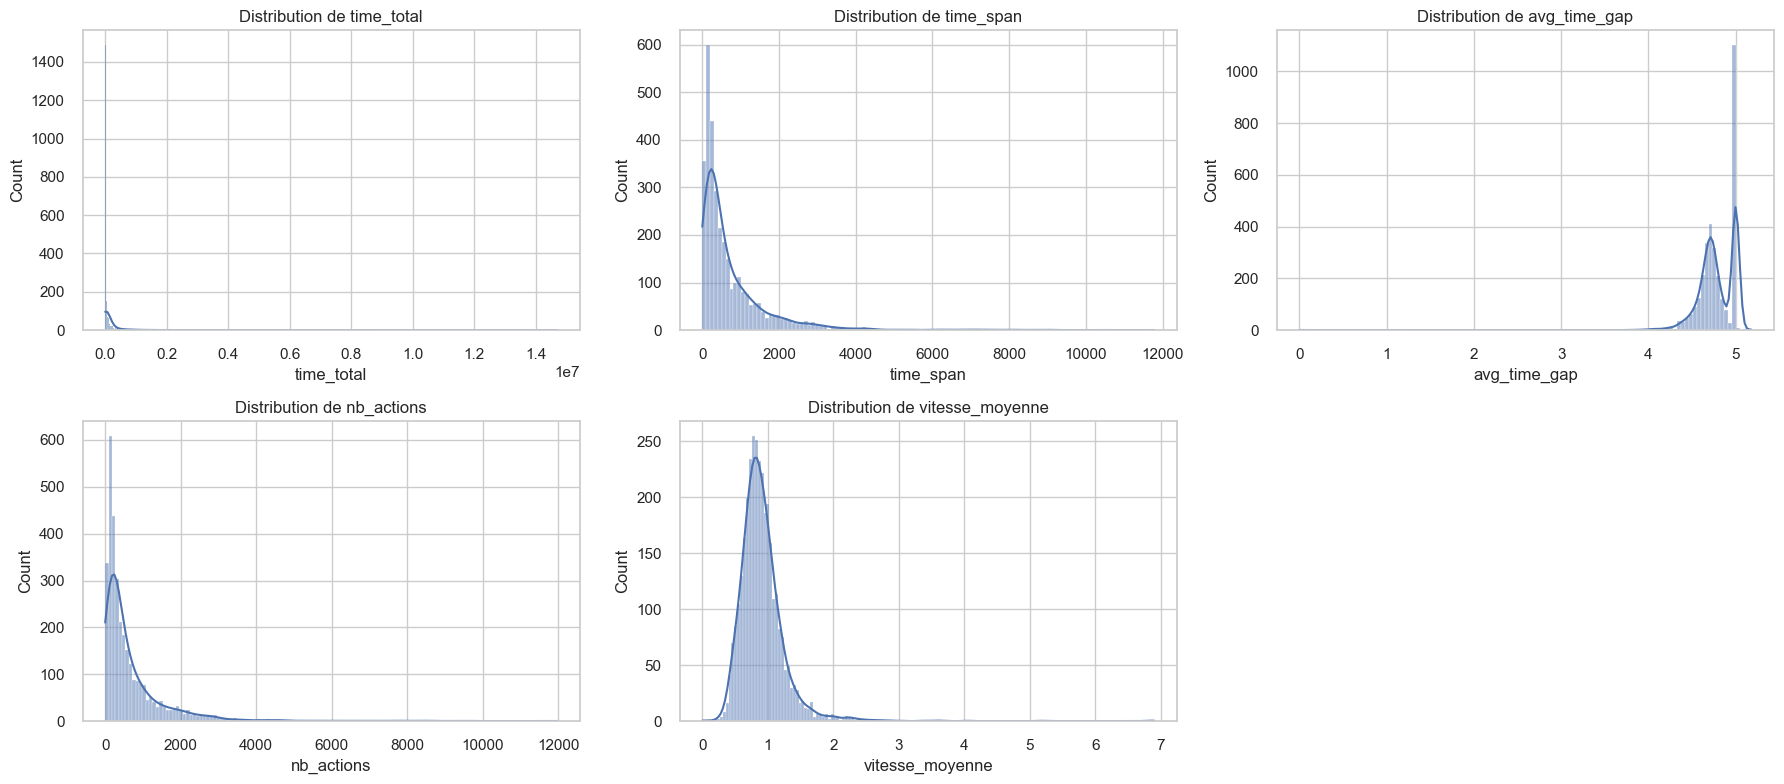

In [5]:
numeric_columns = df_features.select_dtypes(include=[np.number]).columns.tolist()
if not numeric_columns:
    print("Aucune variable numérique détectée dans df_features.")
else:
    numeric_variances = df_features[numeric_columns].var().sort_values(ascending=False)
    top_numeric = numeric_variances.head(12).index.tolist()
    rows = math.ceil(len(top_numeric) / 3)
    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, top_numeric):
        sns.histplot(df_features[col].dropna(), kde=True, ax=ax)
        ax.set_title(f"Distribution de {col}")
    for ax in axes[len(top_numeric):]:
        ax.axis("off")
    plt.tight_layout()


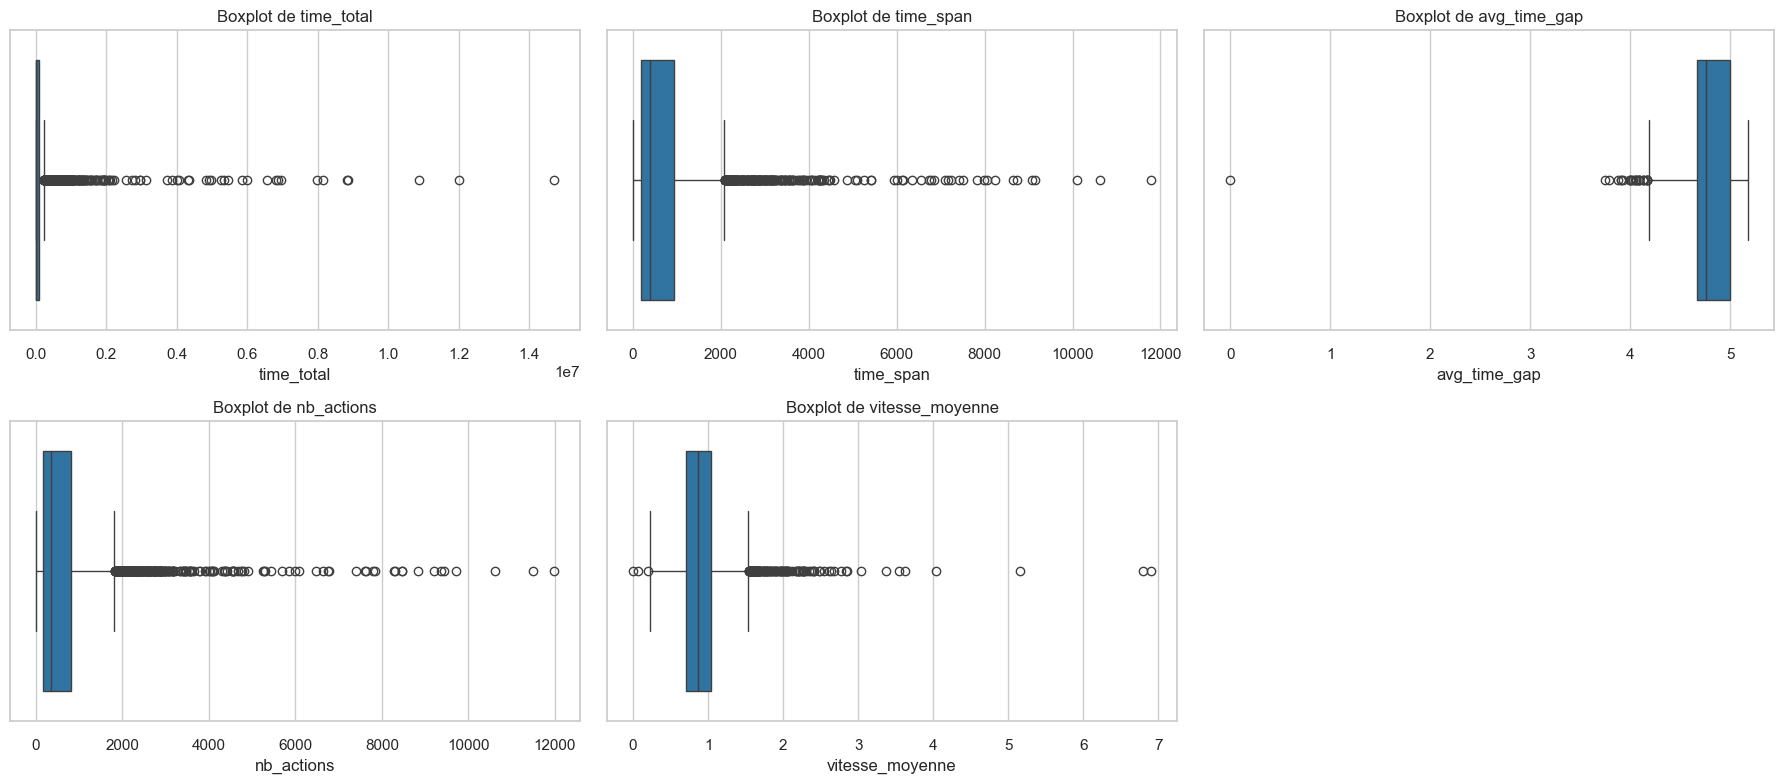

In [6]:
numeric_columns = df_features.select_dtypes(include=[np.number]).columns.tolist()
if numeric_columns:
    numeric_variances = df_features[numeric_columns].var().sort_values(ascending=False)
    top_numeric = numeric_variances.head(12).index.tolist()
    rows = math.ceil(len(top_numeric) / 3)
    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, top_numeric):
        sns.boxplot(x=df_features[col], ax=ax, color="#1f77b4")
        ax.set_title(f"Boxplot de {col}")
    for ax in axes[len(top_numeric):]:
        ax.axis("off")
    plt.tight_layout()
else:
    print("Aucune variable numérique détectée dans df_features.")


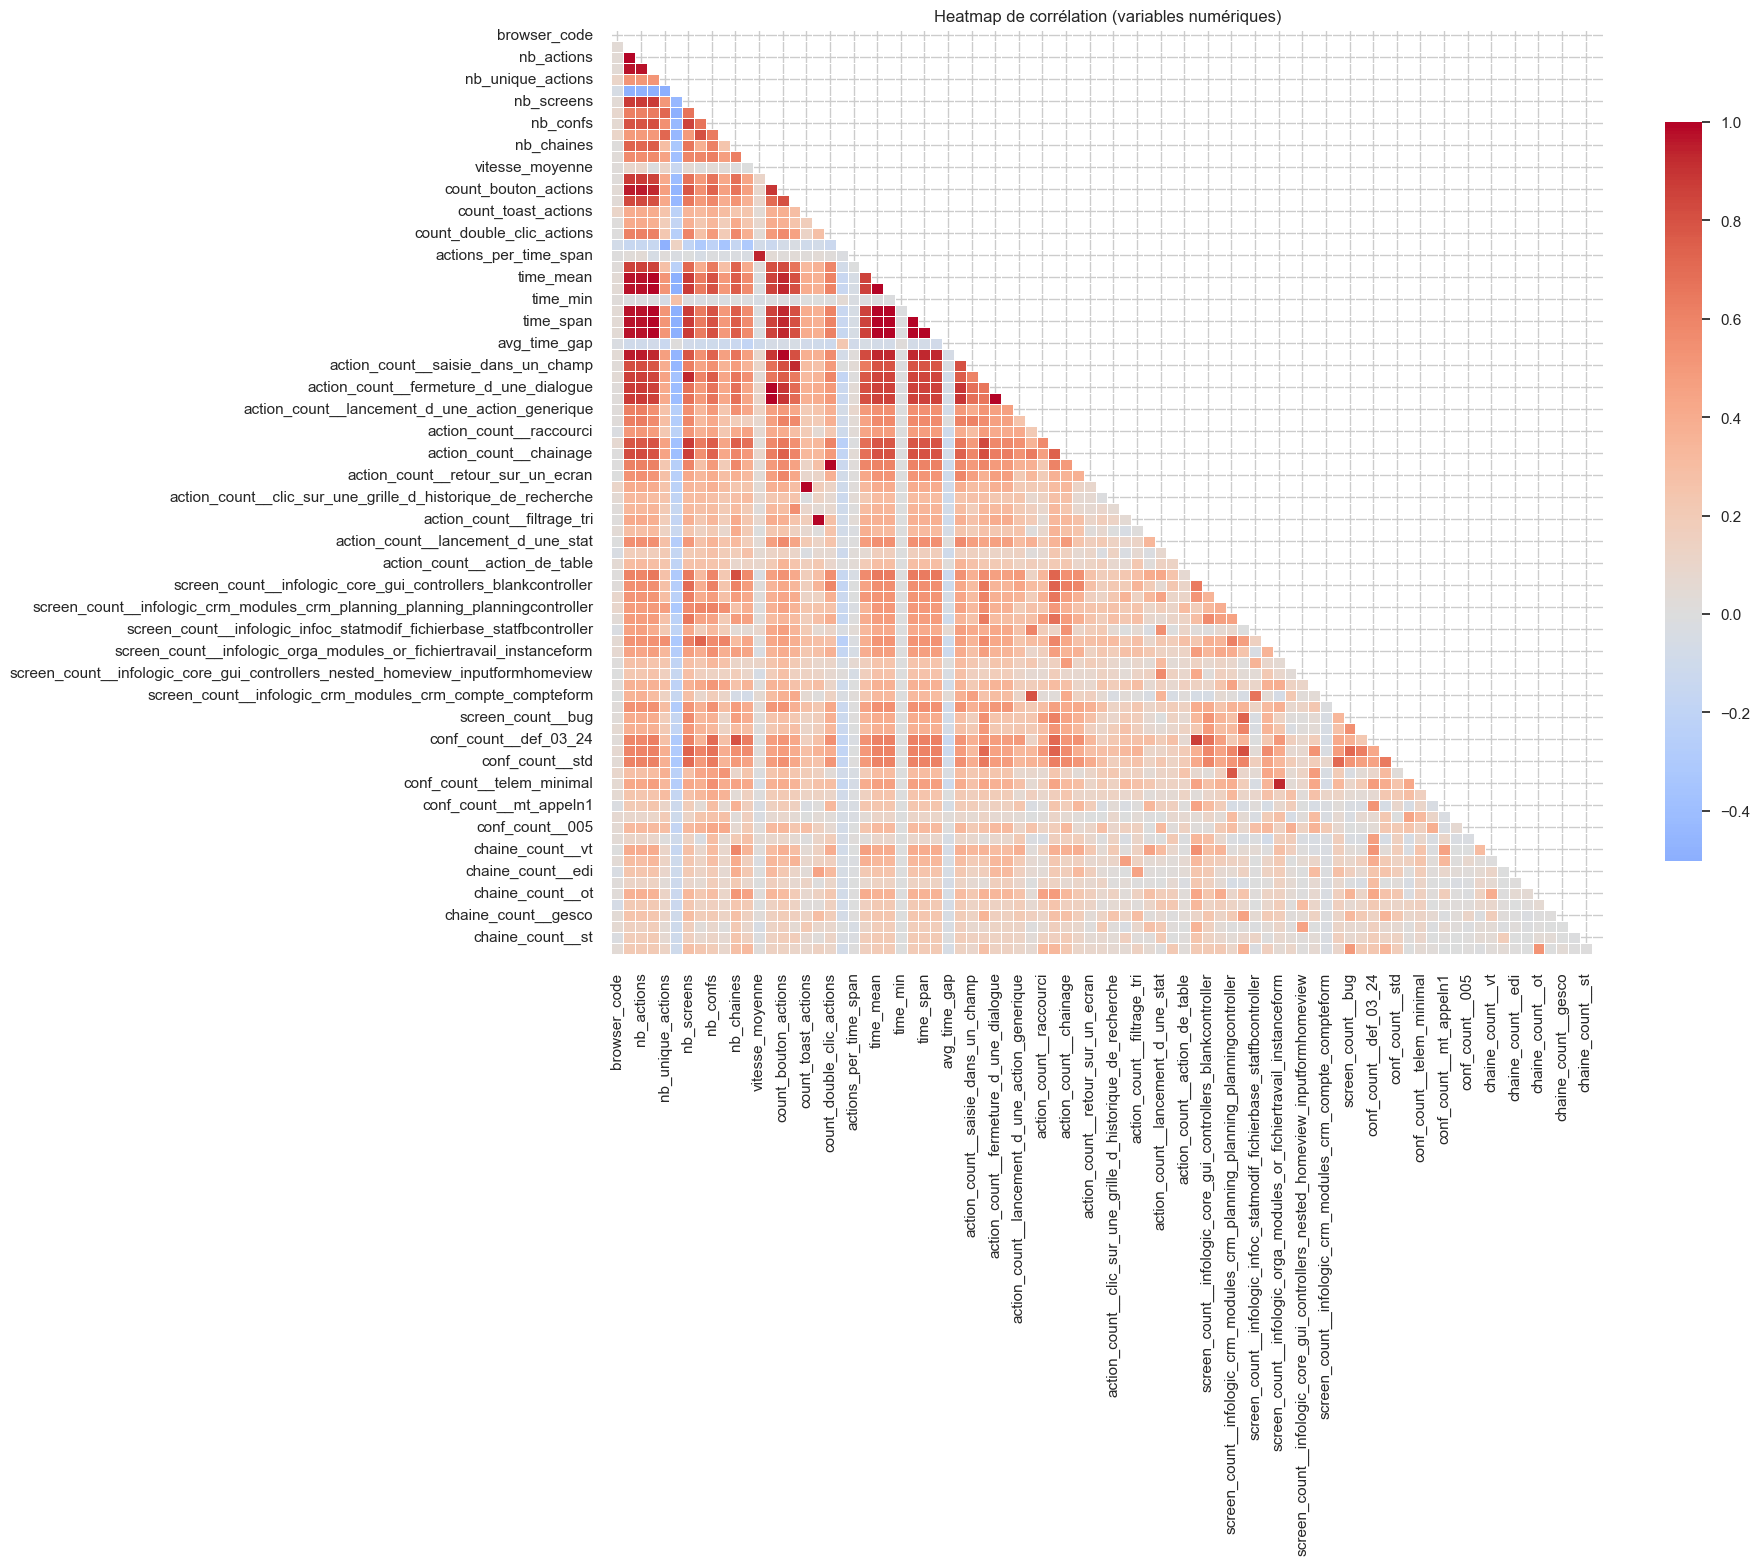

In [7]:
numeric_df = df_features.select_dtypes(include=[np.number])
if numeric_df.shape[1] > 1:
    corr_matrix = numeric_df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    plt.figure(figsize=(16, 12))
    sns.heatmap(
        corr_matrix,
        cmap="coolwarm",
        center=0,
        mask=mask,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Heatmap de corrélation (variables numériques)")
    plt.show()
else:
    print("Pas assez de variables numériques pour une heatmap de corrélation.")


### 4️⃣ Nettoyage et préparation


In [12]:
target_col = "user"

if target_col not in df_features.columns:
    raise KeyError(f"La colonne cible '{target_col}' est introuvable dans df_features.")

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_features[target_col])
X = df_features.drop(columns=[target_col]).copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Nombre de colonnes numériques : {len(numeric_features)}")
print(f"Nombre de colonnes catégorielles : {len(categorical_features)}")
print(f"Nombre de classes cibles : {len(target_encoder.classes_)}")

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_encoder_kwargs = {"handle_unknown": "ignore"}
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(**categorical_encoder_kwargs)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


Nombre de colonnes numériques : 84
Nombre de colonnes catégorielles : 5
Nombre de classes cibles : 247


### 5️⃣ Séparation des données


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train classes : {len(np.unique(y_train))}")
print(f"y_test classes  : {len(np.unique(y_test))}")


X_train shape : (2623, 89)
X_test shape  : (656, 89)
y_train classes : 247
y_test classes  : 247


### 6️⃣ Modélisation et tuning


In [16]:
model_specs = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, multi_class="auto"),
        {
            "model__C": [0.1, 1.0, 10.0],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs"],
        },
    ),
    "SVM (Linear)": (
        SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
        {
            "model__C": [0.5, 1.0, 5.0],
        },
    ),
    "SVM (RBF)": (
        SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        {
            "model__C": [1.0, 5.0],
            "model__gamma": ["scale", "auto"],
        },
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 20, 40],
            "model__min_samples_split": [2, 5],
        },
    ),
}

if XGBClassifier is not None:
    model_specs["XGBoost"] = (
        XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            tree_method="hist",
            n_jobs=-1,
        ),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.05, 0.1],
        },
    )
else:
    print("XGBoost indisponible : installez xgboost pour inclure ce modèle.")

results = []
best_models = {}

for model_name, (estimator, param_grid) in model_specs.items():
    print(f"=== {model_name} ===")
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=1,
    )

    start_time = time.time()
    search.fit(X_train, y_train)
    train_time = time.time() - start_time

    best_pipeline = search.best_estimator_
    best_models[model_name] = best_pipeline

    y_pred = best_pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    roc_auc = np.nan
    if hasattr(best_pipeline, "predict_proba"):
        try:
            y_scores = best_pipeline.predict_proba(X_test)
            roc_auc = roc_auc_score(y_test, y_scores, multi_class="ovr", average="macro")
        except Exception as exc:
            print(f"ROC-AUC non calculable pour {model_name} : {exc}")
    elif hasattr(best_pipeline, "decision_function"):
        try:
            decision_scores = best_pipeline.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, decision_scores, multi_class="ovr", average="macro")
        except Exception as exc:
            print(f"ROC-AUC non calculable pour {model_name} : {exc}")

    print(f"Meilleurs hyperparamètres : {search.best_params_}")
    print(f"Score CV (f1_macro)    : {search.best_score_:.4f}")
    print(f"Temps d'entraînement   : {train_time:.2f} s")
    print(f"Accuracy (test)        : {accuracy:.4f}")
    print(f"Precision (test)       : {precision:.4f}")
    print(f"Recall (test)          : {recall:.4f}")
    print(f"F1-score (test)        : {f1:.4f}")
    print(f"ROC-AUC (test)         : {roc_auc if not np.isnan(roc_auc) else 'N/A'}")

    class_count = len(target_encoder.classes_)
    if class_count <= 30:
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_)
        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
        ax.set_title(f"Confusion Matrix - {model_name}")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Confusion matrix non affichée (trop de classes : {class_count}).")

    if class_count <= 30:
        print("Classification report :")
        print(
            classification_report(
                y_test,
                y_pred,
                target_names=target_encoder.classes_,
                zero_division=0,
            )
        )
    else:
        print("Rapport de classification non affiché (trop de classes).")

    results.append(
        {
            "model": model_name,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": roc_auc,
            "train_time": train_time,
        }
    )


=== Logistic Regression ===
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Meilleurs hyperparamètres : {'model__C': 10.0, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Score CV (f1_macro)    : 0.6846
Temps d'entraînement   : 23.75 s
Accuracy (test)        : 0.7683
Precision (test)       : 0.7346
Recall (test)          : 0.7171
F1-score (test)        : 0.7029
ROC-AUC (test)         : 0.9846612973765615
Confusion matrix non affichée (trop de classes : 247).
Rapport de classification non affiché (trop de classes).
=== SVM (Linear) ===
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Meilleurs hyperparamètres : {'model__C': 5.0}
Score CV (f1_macro)    : 0.6323
Temps d'entraînement   : 21.18 s
Accuracy (test)        : 0.7210
Precision (test)       : 0.6863
Recall (test)          : 0.6789
F1-score (test)        : 0.6606
ROC-AUC (test)         : 0.9773175242722768
Confusion matrix non affichée (trop de classes : 247).
Rapport de classification non affiché (trop de 

In [17]:
results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
print("Résultats comparatifs :")
display(results_df)


Résultats comparatifs :


,model,accuracy,precision,recall,f1,roc_auc,train_time
0,Random Forest,0.823,0.789,0.767,0.759,0.993,104.410
1,XGBoost,0.782,0.737,0.731,0.715,0.985,618.307
2,Logistic Regression,0.768,0.735,0.717,0.703,0.985,23.748
3,SVM (Linear),0.721,0.686,0.679,0.661,0.977,21.184
4,SVM (RBF),0.678,0.645,0.607,0.596,0.967,33.566


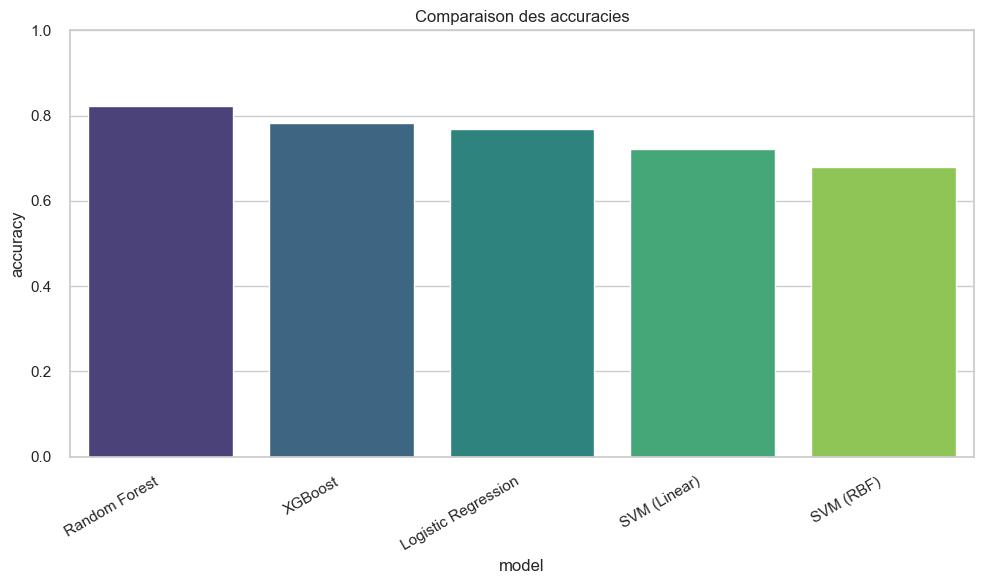

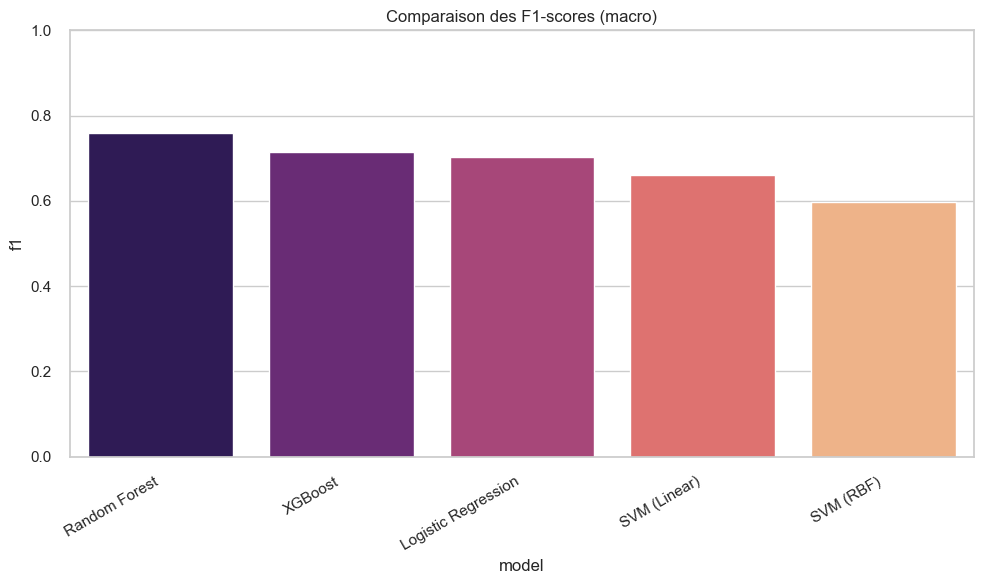

In [18]:
if not results_df.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=results_df, x="model", y="accuracy", palette="viridis")
    plt.title("Comparaison des accuracies")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=results_df, x="model", y="f1", palette="magma")
    plt.title("Comparaison des F1-scores (macro)")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Le tableau des résultats est vide : vérifier l'étape de modélisation.")


### 7️⃣ Interprétation du modèle final


Modèle sélectionné : Random Forest


,feature,importance
36,num__action_count__raccourci,0.021
42,num__action_count__clic_sur_une_grille_d_histo...,0.021
40,num__action_count__retour_sur_un_ecran,0.017
20,num__actions_per_time_span,0.016
19,num__main_action_share,0.016
12,num__vitesse_moyenne,0.015
16,num__count_toast_actions,0.015
57,num__screen_count__infologic_core_accueil_accu...,0.015
0,num__browser_code,0.015
17,num__count_filtrage_actions,0.015


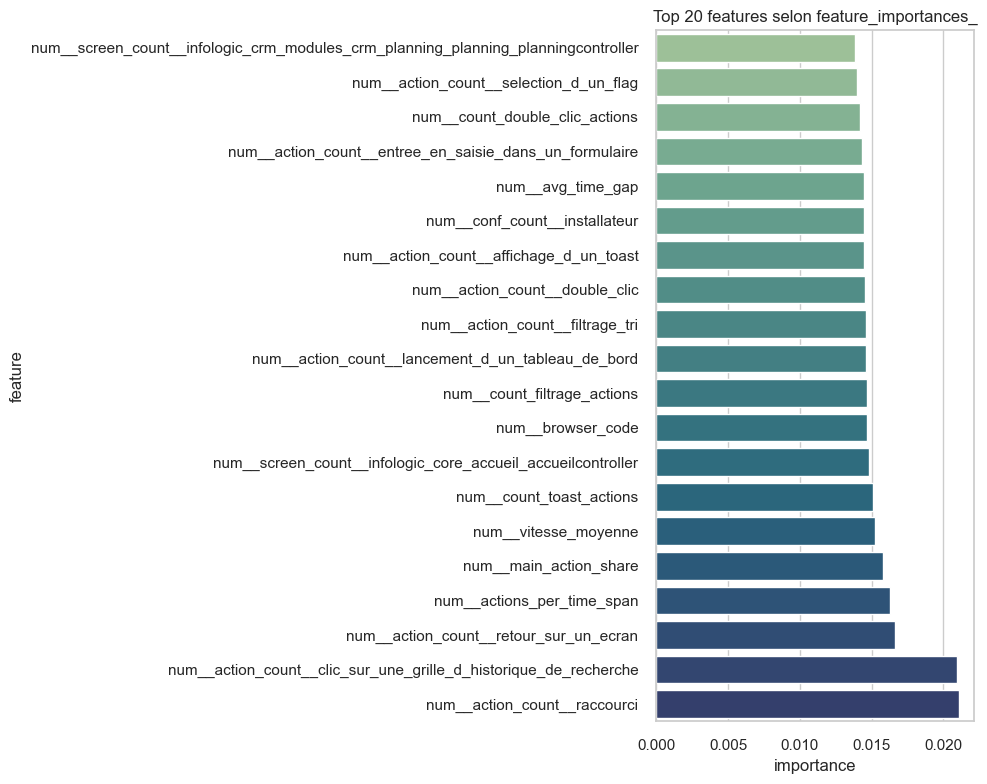

In [19]:
if results_df.empty:
    raise RuntimeError("Aucun résultat de modèle disponible pour l'interprétation.")

best_model_name = results_df.iloc[0]["model"]
print(f"Modèle sélectionné : {best_model_name}")

best_pipeline = best_models[best_model_name]
preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
model_fitted = best_pipeline.named_steps["model"]

try:
    feature_names = preprocessor_fitted.get_feature_names_out()
except AttributeError:
    feature_names = np.array(numeric_features + categorical_features)

importance_values = None
importance_type = None

if hasattr(model_fitted, "feature_importances_"):
    importance_values = model_fitted.feature_importances_
    importance_type = "feature_importances_"
elif hasattr(model_fitted, "coef_"):
    coef_ = model_fitted.coef_
    if coef_.ndim == 1:
        importance_values = np.abs(coef_)
    else:
        importance_values = np.mean(np.abs(coef_), axis=0)
    importance_type = "|coef| (moyenne multi-classes)"

if importance_values is not None:
    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importance_values})
        .sort_values(by="importance", ascending=False)
        .head(20)
    )
    display(importance_df)

    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=importance_df.sort_values(by="importance"),
        x="importance",
        y="feature",
        palette="crest",
    )
    plt.title(f"Top 20 features selon {importance_type}")
    plt.tight_layout()
    plt.show()
else:
    print("Le modèle sélectionné ne fournit pas d'attribut d'importance interprétable directement.")


In [20]:
try:
    import shap

    shap.initjs()

    transformer = best_pipeline.named_steps["preprocessor"]
    model_estimator = best_pipeline.named_steps["model"]

    X_train_transformed = transformer.transform(X_train)
    X_test_transformed = transformer.transform(X_test)

    sample_size = min(200, X_test_transformed.shape[0])
    sample_data = X_test_transformed[:sample_size]

    explainer = shap.Explainer(model_estimator, X_train_transformed)
    shap_values = explainer(sample_data)

    shap.summary_plot(shap_values, feature_names=feature_names, plot_type="bar")
except Exception as exc:
    print(f"Analyse SHAP non disponible : {exc}")


Analyse SHAP non disponible : No module named 'shap'


### 8️⃣ Sauvegarde


In [ ]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

pipeline_path = artifacts_dir / "pipeline.joblib"
model_path = artifacts_dir / "model_final.joblib"
label_encoder_path = artifacts_dir / "target_encoder.joblib"

joblib.dump(best_pipeline, pipeline_path)
joblib.dump(best_pipeline, model_path)
joblib.dump(
    {
        "label_encoder": target_encoder,
        "classes": target_encoder.classes_.tolist(),
    },
    label_encoder_path,
)

print(f"Pipeline sauvegardée : {pipeline_path.resolve()}")
print(f"Modèle sauvegardé   : {model_path.resolve()}")
print(f"Encodeur sauvegardé : {label_encoder_path.resolve()}")


### 9️⃣ Conclusion

- **Modèle retenu** : Random Forest

- **Pistes futures** : Vectorization + stacking
